In [ ]:
# 드라이브 수정

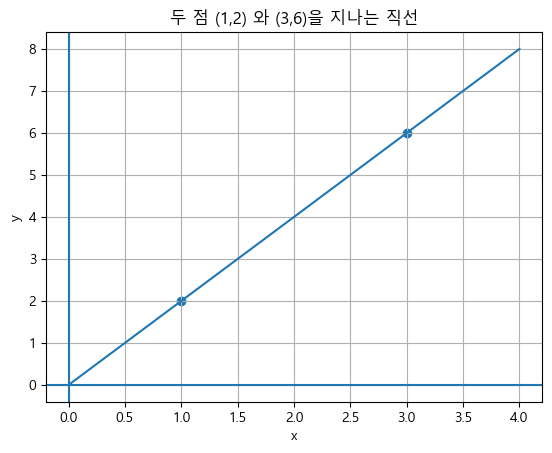

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import rc

rc('font', family='Malgun Gothic')   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False

# 두 점 설정
x1, y1 = 1, 2
x2, y2 = 3, 6

# 직선 생성
x = np.linspace(0, 4, 100)
slope = (y2 - y1) / (x2 - x1)
y = slope * (x - x1) + y1

# 그래프
plt.figure()
plt.plot(x, y)              # 직선
plt.scatter([x1, x2], [y1, y2])  # 두 점
plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.title("두 점 (1,2) 와 (3,6)을 지나는 직선")
plt.xlabel("x")
plt.ylabel("y")

plt.show()


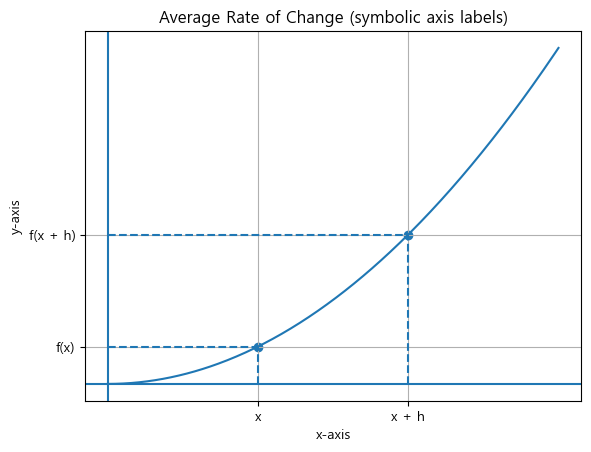

In [2]:
# x축 눈금을 숫자 대신 'x', 'x+h' 로,
# y축 눈금을 'f(x)', 'f(x+h)' 로 표시한 그래프

import numpy as np
import matplotlib.pyplot as plt

# 함수
def f(x):
    return x**2

# 기준값 (실제 계산용)
x_val = 1.0
h = 1.0

# 실제 좌표
x1, y1 = x_val, f(x_val)
x2, y2 = x_val + h, f(x_val + h)

# 곡선
xs = np.linspace(0, 3, 400)
ys = f(xs)

plt.figure()
plt.plot(xs, ys)                         # 함수 그래프
plt.scatter([x1, x2], [y1, y2])          # 점 A, B

# 점선
plt.vlines([x1, x2], ymin=0, ymax=[y1, y2], linestyles='dashed')
plt.hlines([y1, y2], xmin=0, xmax=[x1, x2], linestyles='dashed')

# 축 눈금 위치 설정
plt.xticks([x1, x2], ['x', 'x + h'])
plt.yticks([y1, y2], ['f(x)', 'f(x + h)'])

plt.axhline(0)
plt.axvline(0)
plt.grid()

plt.title("Average Rate of Change (symbolic axis labels)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")

plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return x**2

x0 = 1.0

# h가 점점 작아지는 시퀀스
hs = np.concatenate([
    np.linspace(1.0, 0.2, 25),
    np.linspace(0.2, 0.02, 25),
    np.linspace(0.02, 0.001, 25)
])

# 곡선
xs = np.linspace(0, 3, 600)
ys = f(xs)

fig, ax = plt.subplots()
ax.plot(xs, ys)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.grid(True)
ax.set_xlim(0, 3)
ax.set_ylim(0, 9.5)
ax.set_title("h decreases: secant → tangent")
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")

# 기준점 A
A = (x0, f(x0))
ax.scatter([A[0]], [A[1]])

# 변하는 점 B, 할선
ptB = ax.scatter([x0 + hs[0]], [f(x0 + hs[0])])
(secant_line,) = ax.plot([], [])

# 보조선들을 dict로 관리(프레임마다 교체)
aux = {}
aux["v1"] = ax.vlines([A[0]], ymin=0, ymax=[A[1]], linestyles='dashed')
aux["v2"] = ax.vlines([x0 + hs[0]], ymin=0, ymax=[f(x0 + hs[0])], linestyles='dashed')
aux["h1"] = ax.hlines([A[1]], xmin=0, xmax=[A[0]], linestyles='dashed')
aux["h2"] = ax.hlines([f(x0 + hs[0])], xmin=0, xmax=[x0 + hs[0]], linestyles='dashed')

# 기호 텍스트(축 눈금 대신)
ax.text(A[0], -0.45, "x", ha="center", va="top")
txt_xh = ax.text(x0 + hs[0], -0.45, "x + h", ha="center", va="top")
ax.text(-0.12, A[1], "f(x)", ha="right", va="center")
txt_fxh = ax.text(-0.12, f(x0 + hs[0]), "f(x+h)", ha="right", va="center")

info = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

def update(i):
    h = float(hs[i])
    B = (x0 + h, f(x0 + h))
    slope = (B[1] - A[1]) / h  # 평균 변화율

    ptB.set_offsets([[B[0], B[1]]])

    # 할선 업데이트
    sx = np.linspace(A[0], B[0], 80)
    sy = A[1] + slope * (sx - A[0])
    secant_line.set_data(sx, sy)

    # 보조선 교체
    for k in list(aux.keys()):
        aux[k].remove()

    aux["v1"] = ax.vlines([A[0]], ymin=0, ymax=[A[1]], linestyles='dashed')
    aux["v2"] = ax.vlines([B[0]], ymin=0, ymax=[B[1]], linestyles='dashed')
    aux["h1"] = ax.hlines([A[1]], xmin=0, xmax=[A[0]], linestyles='dashed')
    aux["h2"] = ax.hlines([B[1]], xmin=0, xmax=[B[0]], linestyles='dashed')

    # 텍스트 위치 업데이트
    txt_xh.set_position((B[0], -0.45))
    txt_fxh.set_position((-0.12, B[1]))

    info.set_text(f"h = {h:.4f}\nsecant slope = (f(x+h)-f(x))/h ≈ {slope:.4f}")
    return (ptB, secant_line, aux["v1"], aux["v2"], aux["h1"], aux["h2"], txt_xh, txt_fxh, info)

ani = FuncAnimation(fig, update, frames=len(hs), interval=80, blit=False)

plt.close(fig)
HTML(ani.to_jshtml())


C:\Users\JYB\AppData\Local\Temp\ipykernel_16472\145352503.py:87: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  HTML(ani.to_jshtml())


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return x**2

def fp(x):
    return 2*x  # 미분값(접선 기울기)

x0 = 1.0
A = (x0, f(x0))

# h가 점점 작아지는 시퀀스
hs = np.concatenate([
    np.linspace(1.0, 0.2, 25),
    np.linspace(0.2, 0.02, 25),
    np.linspace(0.02, 0.001, 25)
])

# 곡선
xs = np.linspace(0, 3, 600)
ys = f(xs)

fig, ax = plt.subplots()
ax.plot(xs, ys)  # 함수
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.grid(True)
ax.set_xlim(0, 3)
ax.set_ylim(0, 9.5)
ax.set_title("h decreases: secant → tangent (with tangent line)")
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")

# 점 A (고정)
ax.scatter([A[0]], [A[1]])

# 접선(고정): y = f(x0) + f'(x0)(x - x0)
tangent_sx = np.linspace(x0-0.8, x0+0.8, 200)
tangent_sy = A[1] + fp(x0) * (tangent_sx - x0)
(ax_tangent,) = ax.plot(tangent_sx, tangent_sy)

# 점 B, 할선(변함)
ptB = ax.scatter([x0 + hs[0]], [f(x0 + hs[0])])
(ax_secant,) = ax.plot([], [])

# 보조선
aux = {}
aux["v1"] = ax.vlines([A[0]], ymin=0, ymax=[A[1]], linestyles='dashed')
aux["v2"] = ax.vlines([x0 + hs[0]], ymin=0, ymax=[f(x0 + hs[0])], linestyles='dashed')
aux["h1"] = ax.hlines([A[1]], xmin=0, xmax=[A[0]], linestyles='dashed')
aux["h2"] = ax.hlines([f(x0 + hs[0])], xmin=0, xmax=[x0 + hs[0]], linestyles='dashed')

# 기호 텍스트
ax.text(A[0], -0.45, "x", ha="center", va="top")
txt_xh = ax.text(x0 + hs[0], -0.45, "x + h", ha="center", va="top")
ax.text(-0.12, A[1], "f(x)", ha="right", va="center")
txt_fxh = ax.text(-0.12, f(x0 + hs[0]), "f(x+h)", ha="right", va="center")

info = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

def update(i):
    h = float(hs[i])
    B = (x0 + h, f(x0 + h))
    secant_slope = (B[1] - A[1]) / h

    # 점 B
    ptB.set_offsets([[B[0], B[1]]])

    # 할선: A~B 구간
    sx = np.linspace(A[0], B[0], 120)
    sy = A[1] + secant_slope * (sx - A[0])
    ax_secant.set_data(sx, sy)

    # 보조선 교체
    for k in list(aux.keys()):
        aux[k].remove()

    aux["v1"] = ax.vlines([A[0]], ymin=0, ymax=[A[1]], linestyles='dashed')
    aux["v2"] = ax.vlines([B[0]], ymin=0, ymax=[B[1]], linestyles='dashed')
    aux["h1"] = ax.hlines([A[1]], xmin=0, xmax=[A[0]], linestyles='dashed')
    aux["h2"] = ax.hlines([B[1]], xmin=0, xmax=[B[0]], linestyles='dashed')

    # 텍스트 업데이트
    txt_xh.set_position((B[0], -0.45))
    txt_fxh.set_position((-0.12, B[1]))

    info.set_text(
        f"h = {h:.4f}\n"
        f"secant slope ≈ {secant_slope:.4f}\n"
        f"tangent slope f'(x) = {fp(x0):.4f}"
    )

    return (ptB, ax_secant, ax_tangent, aux["v1"], aux["v2"], aux["h1"], aux["h2"], txt_xh, txt_fxh, info)

ani = FuncAnimation(fig, update, frames=len(hs), interval=80, blit=False)

plt.close(fig)
HTML(ani.to_jshtml())


C:\Users\JYB\AppData\Local\Temp\ipykernel_16472\410063212.py:101: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  HTML(ani.to_jshtml())
